# Phase 3 — Graph Construction

**Goal:** Convert the preprocessed UNSW-NB15 flow data into a PyTorch Geometric `Data` object.

```
Graph G = (V, E)
  Nodes V  : 50 unique IP addresses  →  node_feat [50+1, 11]  (+1 UNK node)
  Edges E  : each network flow       →  directed edge (srcip → dstip)
             edge_feat = 37 flow-level features (RobustScaled)
             edge_label = y_binary (0/1) + y_multiclass (0–9)
  edge_index : COO format [2, num_edges], directed
```

**Inputs (Phase 2 outputs):**
- `outputs/preprocessed/X_{train,val,test}.npy` — scaled edge feature matrices
- `outputs/preprocessed/y_binary_*.npy` / `y_multiclass_*.npy` — labels
- `outputs/preprocessed/node_features.csv` — per-IP node features
- `outputs/preprocessed/ip_to_node.json` — IP → node index map

**Outputs (Phase 3):**
- `outputs/graph/graph_data_{train,val,test}.pt`
- `outputs/graph/graph_stats.json`

In [1]:
import os, json, pickle, warnings, gc
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE    = r'c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15'
OUT_PRE = os.path.join(BASE, 'outputs', 'preprocessed')
OUT_ENC = os.path.join(BASE, 'outputs', 'encoders')
OUT_GRF = os.path.join(BASE, 'outputs', 'graph')
OUT_EDA = os.path.join(BASE, 'outputs', 'eda')
os.makedirs(OUT_GRF, exist_ok=True)

# ── Same column schema as Phase 2 ─────────────────────────────────────────────
COLUMNS = [
    'srcip','sport','dstip','dsport','proto','state',
    'dur','sbytes','dbytes','sttl','dttl','sloss','dloss',
    'service','Sload','Dload','Spkts','Dpkts',
    'swin','dwin','stcpb','dtcpb','smeansz','dmeansz',
    'trans_depth','res_bdy_len','Sjit','Djit',
    'Stime','Ltime','Sintpkt','Dintpkt',
    'tcprtt','synack','ackdat',
    'is_sm_ips_ports','ct_state_ttl','ct_flw_http_mthd',
    'is_ftp_login','ct_ftp_cmd',
    'ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm',
    'attack_cat','label'
]
NULL_FILL_ZERO = ['ct_flw_http_mthd', 'is_ftp_login']
IP_COLS        = ['srcip', 'dstip']
OFFICIAL_TEST  = os.path.join(
    BASE, 'Training and Testing Sets', 'UNSW_NB15_testing-set.csv')

import torch_geometric
print(f'PyTorch         : {torch.__version__}')
print(f'PyG             : {torch_geometric.__version__}')
print(f'NetworkX        : {nx.__version__}')
print(f'Graph outputs → {OUT_GRF}')

PyTorch         : 2.12.0+cpu
PyG             : 2.8.0
NetworkX        : 3.6.1
Graph outputs → c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15\outputs\graph


## 3.1 — Load Preprocessed Arrays

Load the `X` matrices (already RobustScaled, float32), labels, and graph metadata produced by Phase 2.

In [2]:
# ── Feature metadata ──────────────────────────────────────────────────────────
with open(os.path.join(OUT_PRE, 'feature_names.json')) as f:
    feat_meta = json.load(f)
FEATURE_NAMES = feat_meta['feature_names']    # 37 features
N_FEAT        = len(FEATURE_NAMES)
CLASS_NAMES   = feat_meta['class_names']      # 10 attack categories

# ── Feature matrices (RobustScaled float32) ───────────────────────────────────
X_train = np.load(os.path.join(OUT_PRE, 'X_train.npy'))
X_val   = np.load(os.path.join(OUT_PRE, 'X_val.npy'))
X_test  = np.load(os.path.join(OUT_PRE, 'X_test.npy'))

# ── Binary labels (0=Normal, 1=Attack) ───────────────────────────────────────
y_bin_train = np.load(os.path.join(OUT_PRE, 'y_binary_train.npy'))
y_bin_val   = np.load(os.path.join(OUT_PRE, 'y_binary_val.npy'))
y_bin_test  = np.load(os.path.join(OUT_PRE, 'y_binary_test.npy'))

# ── Multiclass labels (0–9) ───────────────────────────────────────────────────
y_multi_train = np.load(os.path.join(OUT_PRE, 'y_multiclass_train.npy'))
y_multi_val   = np.load(os.path.join(OUT_PRE, 'y_multiclass_val.npy'))
y_multi_test  = np.load(os.path.join(OUT_PRE, 'y_multiclass_test.npy'))

# ── Node metadata ─────────────────────────────────────────────────────────────
with open(os.path.join(OUT_PRE, 'node_features_meta.json')) as f:
    node_meta = json.load(f)
NODE_FEAT_COLS = node_meta['node_feat_cols']  # 11 columns
N_NODE_FEAT    = node_meta['node_feat_dim']

# ── IP → node index map ───────────────────────────────────────────────────────
with open(os.path.join(OUT_PRE, 'ip_to_node.json')) as f:
    ip_to_node = json.load(f)

N_NODES_BASE = len(ip_to_node)      # 50
UNK_NODE_IDX = N_NODES_BASE         # 50 — reserved for IPs not in training map
N_NODES      = N_NODES_BASE + 1     # 51 (50 known + 1 UNK)

print('=== Loaded Phase 2 Outputs ===')
print(f'Feature matrices:')
print(f'  X_train : {X_train.shape}  dtype={X_train.dtype}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'\nLabels (binary / multiclass):')
print(f'  Train  : {y_bin_train.shape}  /  {y_multi_train.shape}')
print(f'  Val    : {y_bin_val.shape}    /  {y_multi_val.shape}')
print(f'  Test   : {y_bin_test.shape}   /  {y_multi_test.shape}')
print(f'\nNode map : {N_NODES_BASE} known IPs  +  1 UNK = {N_NODES} total nodes')
print(f'Node feat: {N_NODE_FEAT} cols → {NODE_FEAT_COLS}')

=== Loaded Phase 2 Outputs ===
Feature matrices:
  X_train : (1647526, 37)  dtype=float32
  X_val   : (411882, 37)
  X_test  : (82332, 37)

Labels (binary / multiclass):
  Train  : (1647526,)  /  (1647526,)
  Val    : (411882,)    /  (411882,)
  Test   : (82332,)   /  (82332,)

Node map : 50 known IPs  +  1 UNK = 51 total nodes
Node feat: 11 cols → ['out_degree', 'mean_sbytes', 'mean_dur', 'unique_dsport', 'unique_proto', 'src_attack_ratio', 'in_degree', 'mean_dbytes', 'dst_attack_ratio', 'total_degree', 'total_bytes']


## 3.2 — Extract Source / Destination IP Columns

`srcip` and `dstip` were **intentionally excluded** from `X_train.npy` in Phase 2 — they are  
graph structure identifiers, not edge features. To build `edge_index`, we need them back.

**Strategy (preprocessed-folder-only after first run):**
- First run: reload raw files, reproduce the Phase 2 dedup + split, extract IPs, then  
  save `srcip_train.npy`, `dstip_train.npy`, `srcip_val.npy`, `dstip_val.npy` to  
  `outputs/preprocessed/` → subsequent runs skip the raw file loading entirely.
- Test set: the official pre-split CSV has **no IP columns** (anonymised). All test flows  
  are assigned to the **UNK node** (index 50) — no CSV loading needed.

In [6]:
SRCIP_TRAIN_PATH = os.path.join(OUT_PRE, 'srcip_train.npy')
DSTIP_TRAIN_PATH = os.path.join(OUT_PRE, 'dstip_train.npy')
SRCIP_VAL_PATH   = os.path.join(OUT_PRE, 'srcip_val.npy')
DSTIP_VAL_PATH   = os.path.join(OUT_PRE, 'dstip_val.npy')

CACHE_EXISTS = all(os.path.exists(p) for p in [
    SRCIP_TRAIN_PATH, DSTIP_TRAIN_PATH, SRCIP_VAL_PATH, DSTIP_VAL_PATH
])

if CACHE_EXISTS:
    # ── Fast path: load cached IP arrays from outputs/preprocessed/ ──────────
    print('IP arrays found in outputs/preprocessed/ — loading from cache...')
    src_train = np.load(SRCIP_TRAIN_PATH, allow_pickle=True)
    dst_train = np.load(DSTIP_TRAIN_PATH, allow_pickle=True)
    src_val   = np.load(SRCIP_VAL_PATH,   allow_pickle=True)
    dst_val   = np.load(DSTIP_VAL_PATH,   allow_pickle=True)
    print(f'  src_train : {src_train.shape}  dst_train : {dst_train.shape}')
    print(f'  src_val   : {src_val.shape}    dst_val   : {dst_val.shape}')
else:
    # ── First run: extract IPs from raw files and save to preprocessed/ ───────
    print('IP arrays not cached — loading raw files to extract srcip/dstip...')
    print('(This is a one-time step; results are saved to outputs/preprocessed/)\n')

    dfs = []
    for i in range(1, 5):
        path = os.path.join(BASE, f'UNSW-NB15_{i}.csv')
        df_i = pd.read_csv(path, header=None, names=COLUMNS,
                           encoding='latin1', low_memory=False)
        # Phase 2: strip UTF-8 BOM from srcip (file 1 artefact)
        df_i['srcip'] = (df_i['srcip'].astype(str)
                         .str.replace('\ufeff', '', regex=False).str.strip())
        # Phase 2: normalize attack_cat
        df_i['attack_cat'] = (df_i['attack_cat'].astype(str).str.strip()
                              .replace({'nan': 'Normal', '': 'Normal', 'Backdoors': 'Backdoor'})
                              .fillna('Normal'))
        # Phase 2: coerce label and port columns
        df_i['label'] = pd.to_numeric(df_i['label'], errors='coerce').fillna(0).astype(int)
        for col in ['sport', 'dsport']:
            df_i[col] = pd.to_numeric(df_i[col], errors='coerce').fillna(0).astype(np.int32)
        print(f'  File {i}: {len(df_i):>9,} rows loaded')
        dfs.append(df_i[['srcip', 'dstip', 'label']])  # only keep what we need

    df_ip = pd.concat(dfs, ignore_index=True)
    del dfs; gc.collect()

    # Phase 2: null fill then dedup (only on IP+label columns — dedup is row-wise)
    df_ip['label'] = pd.to_numeric(df_ip['label'], errors='coerce').fillna(0).astype(int)

    # Reproduce the FULL dedup on all 49 columns is required for exact row alignment.
    # Since we only have 3 cols here, reload full data for accurate dedup:
    print('\nReloading full rows for accurate deduplication...')
    dfs_full = []
    for i in range(1, 5):
        path = os.path.join(BASE, f'UNSW-NB15_{i}.csv')
        df_i = pd.read_csv(path, header=None, names=COLUMNS,
                           encoding='latin1', low_memory=False)
        df_i['srcip'] = (df_i['srcip'].astype(str)
                         .str.replace('\ufeff', '', regex=False).str.strip())
        df_i['attack_cat'] = (df_i['attack_cat'].astype(str).str.strip()
                              .replace({'nan': 'Normal', '': 'Normal', 'Backdoors': 'Backdoor'})
                              .fillna('Normal'))
        df_i['label'] = pd.to_numeric(df_i['label'], errors='coerce').fillna(0).astype(int)
        for col in ['sport', 'dsport']:
            df_i[col] = pd.to_numeric(df_i[col], errors='coerce').fillna(0).astype(np.int32)
        dfs_full.append(df_i)

    df = pd.concat(dfs_full, ignore_index=True)
    df['attack_cat'] = df['attack_cat'].fillna('Normal')
    del dfs_full, df_ip; gc.collect()

    for c in NULL_FILL_ZERO:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
    skip_coerce = set(IP_COLS + ['proto', 'service', 'state', 'attack_cat'])
    for c in df.columns:
        if c not in skip_coerce:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

    n_before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    n_after  = len(df)
    print(f'Dedup: {n_before:,} → {n_after:,} rows  ({n_before - n_after:,} dropped)')

    ip_label_df = df[['srcip', 'dstip', 'label']].copy()
    del df; gc.collect()

    # Phase 2: same stratified split (random_state=42)
    y_bin_all = ip_label_df['label'].values
    indices   = np.arange(len(ip_label_df))
    train_idx, val_idx = train_test_split(
        indices, test_size=0.2, random_state=42, stratify=y_bin_all
    )

    src_train = ip_label_df['srcip'].values[train_idx].astype(str)
    dst_train = ip_label_df['dstip'].values[train_idx].astype(str)
    src_val   = ip_label_df['srcip'].values[val_idx].astype(str)
    dst_val   = ip_label_df['dstip'].values[val_idx].astype(str)
    del ip_label_df; gc.collect()

    # ── Save to outputs/preprocessed/ for future runs ─────────────────────────
    np.save(SRCIP_TRAIN_PATH, src_train)
    np.save(DSTIP_TRAIN_PATH, dst_train)
    np.save(SRCIP_VAL_PATH,   src_val)
    np.save(DSTIP_VAL_PATH,   dst_val)
    print(f'\nSaved IP arrays to outputs/preprocessed/:')
    print(f'  srcip_train.npy  ({len(src_train):,})')
    print(f'  dstip_train.npy  ({len(dst_train):,})')
    print(f'  srcip_val.npy    ({len(src_val):,})')
    print(f'  dstip_val.npy    ({len(dst_val):,})')

# Sanity-check row alignment
assert len(src_train) == X_train.shape[0], \
    f'Train row mismatch: IPs={len(src_train)}, X_train={X_train.shape[0]}'
assert len(src_val) == X_val.shape[0], \
    f'Val row mismatch: IPs={len(src_val)}, X_val={X_val.shape[0]}'
print(f'\nTrain IPs : {len(src_train):>9,}  ✓ row-aligned with X_train')
print(f'Val   IPs : {len(src_val):>9,}  ✓ row-aligned with X_val')

# ── Test set: official CSV has NO IP columns → all test edges → UNK node ──────
print(f'Test  IPs : {X_test.shape[0]:>9,}  → all assigned to UNK node (no IPs in test CSV)')
src_test = np.full(X_test.shape[0], '__UNK__', dtype=object)
dst_test = np.full(X_test.shape[0], '__UNK__', dtype=object)

IP arrays not cached — loading raw files to extract srcip/dstip...
(This is a one-time step; results are saved to outputs/preprocessed/)

  File 1:   700,001 rows loaded
  File 2:   700,001 rows loaded
  File 3:   700,001 rows loaded
  File 4:   440,044 rows loaded

Reloading full rows for accurate deduplication...
Dedup: 2,540,047 → 2,059,408 rows  (480,639 dropped)

Saved IP arrays to outputs/preprocessed/:
  srcip_train.npy  (1,647,526)
  dstip_train.npy  (1,647,526)
  srcip_val.npy    (411,882)
  dstip_val.npy    (411,882)

Train IPs : 1,647,526  ✓ row-aligned with X_train
Val   IPs :   411,882  ✓ row-aligned with X_val
Test  IPs :    82,332  → all assigned to UNK node (no IPs in test CSV)


## 3.3 — Build `edge_index` COO Tensors

Map each flow's `(srcip, dstip)` pair to `(src_node_idx, dst_node_idx)` using `ip_to_node.json`.  
IPs not present in the training map are assigned to the **UNK node** (index 50).

> Edges remain **directed** — `srcip → dstip` asymmetry encodes flow direction, which is
> informative for attack detection (e.g., scans generate high out-degree from attacker IPs).

In [7]:
def map_ips_to_node_indices(ip_array: np.ndarray,
                            ip_map: dict,
                            unk_idx: int) -> np.ndarray:
    """Vectorised IP-string → node-index lookup; unknowns → unk_idx."""
    return np.fromiter(
        (ip_map.get(str(ip), unk_idx) for ip in ip_array),
        dtype=np.int64,
        count=len(ip_array)
    )

# ── Build COO arrays ──────────────────────────────────────────────────────────
src_train_idx = map_ips_to_node_indices(src_train, ip_to_node, UNK_NODE_IDX)
dst_train_idx = map_ips_to_node_indices(dst_train, ip_to_node, UNK_NODE_IDX)

src_val_idx   = map_ips_to_node_indices(src_val,   ip_to_node, UNK_NODE_IDX)
dst_val_idx   = map_ips_to_node_indices(dst_val,   ip_to_node, UNK_NODE_IDX)

src_test_idx  = map_ips_to_node_indices(src_test,  ip_to_node, UNK_NODE_IDX)
dst_test_idx  = map_ips_to_node_indices(dst_test,  ip_to_node, UNK_NODE_IDX)

# ── Convert to torch.long tensors (required by PyG) ──────────────────────────
edge_index_train = torch.from_numpy(np.stack([src_train_idx, dst_train_idx])).long()
edge_index_val   = torch.from_numpy(np.stack([src_val_idx,   dst_val_idx  ])).long()
edge_index_test  = torch.from_numpy(np.stack([src_test_idx,  dst_test_idx ])).long()

# ── Coverage report ──────────────────────────────────────────────────────────
for name, si, di in [
    ('Train', src_train_idx, dst_train_idx),
    ('Val',   src_val_idx,   dst_val_idx),
    ('Test',  src_test_idx,  dst_test_idx),
]:
    unk_src = (si == UNK_NODE_IDX).sum()
    unk_dst = (di == UNK_NODE_IDX).sum()
    print(f'{name:5s} edge_index : shape={np.stack([si,di]).shape}  '
          f'dtype=int64  '
          f'UNK-src={unk_src:,}  UNK-dst={unk_dst:,}')

print(f'\nedge_index dtype checks:')
print(f'  Train : {edge_index_train.dtype}  shape={tuple(edge_index_train.shape)}')
print(f'  Val   : {edge_index_val.dtype}    shape={tuple(edge_index_val.shape)}')
print(f'  Test  : {edge_index_test.dtype}   shape={tuple(edge_index_test.shape)}')
assert edge_index_train.dtype == torch.long
assert edge_index_val.dtype   == torch.long
assert edge_index_test.dtype  == torch.long
print('✓ All edge_index tensors are torch.long')

Train edge_index : shape=(2, 1647526)  dtype=int64  UNK-src=0  UNK-dst=0
Val   edge_index : shape=(2, 411882)  dtype=int64  UNK-src=0  UNK-dst=0
Test  edge_index : shape=(2, 82332)  dtype=int64  UNK-src=82,332  UNK-dst=82,332

edge_index dtype checks:
  Train : torch.int64  shape=(2, 1647526)
  Val   : torch.int64    shape=(2, 411882)
  Test  : torch.int64   shape=(2, 82332)
✓ All edge_index tensors are torch.long


## 3.4 — Build Node Feature Tensor

Load `node_features.csv` (50 × 11), apply `RobustScaler` (fit on train nodes — trivial since all
50 nodes are "training" nodes), then append one **zero row** for the UNK node.

Val/test graphs share the same node feature matrix (no recomputation — anti-leakage).

In [8]:
# ── Load node features ────────────────────────────────────────────────────────
node_feat_df = pd.read_csv(os.path.join(OUT_PRE, 'node_features.csv'))
# Columns: ip + 11 feature cols
node_feat_arr = node_feat_df[NODE_FEAT_COLS].values.astype(np.float32)   # [50, 11]

print(f'node_feat_df shape : {node_feat_df.shape}')
print(f'node_feat_arr      : {node_feat_arr.shape}  dtype={node_feat_arr.dtype}')

# ── RobustScale node features (fit on all 50 train nodes — no leakage) ────────
node_scaler = RobustScaler()
node_feat_scaled = node_scaler.fit_transform(node_feat_arr).astype(np.float32)

# ── Append UNK node row (zeros in scaled space) ───────────────────────────────
unk_row = np.zeros((1, N_NODE_FEAT), dtype=np.float32)
node_feat_full = np.vstack([node_feat_scaled, unk_row])   # [51, 11]

# ── Convert to tensor ─────────────────────────────────────────────────────────
node_feat_tensor = torch.from_numpy(node_feat_full).float()   # [51, 11]

print(f'\nAfter RobustScale + UNK row:')
print(f'  node_feat_tensor : {tuple(node_feat_tensor.shape)}  dtype={node_feat_tensor.dtype}')
print(f'  min={node_feat_tensor.min():.3f}  max={node_feat_tensor.max():.3f}  mean={node_feat_tensor.mean():.3f}')
print(f'  UNK row (index {UNK_NODE_IDX}): {node_feat_tensor[UNK_NODE_IDX].tolist()}')
assert node_feat_tensor.dtype == torch.float32
assert node_feat_tensor.shape == (N_NODES, N_NODE_FEAT)
print(f'✓ node_feat_tensor shape [{N_NODES}, {N_NODE_FEAT}] correct')

node_feat_df shape : (50, 12)
node_feat_arr      : (50, 11)  dtype=float32

After RobustScale + UNK row:
  node_feat_tensor : (51, 11)  dtype=torch.float32
  min=-2.000  max=130.000  mean=2.358
  UNK row (index 50): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
✓ node_feat_tensor shape [51, 11] correct


## 3.5 — Build Edge Feature Tensors

`X_train.npy` / `X_val.npy` / `X_test.npy` are already `RobustScaled` float32 from Phase 2.  
Convert directly to `torch.FloatTensor` — no further transformation needed.

In [9]:
edge_attr_train = torch.from_numpy(X_train).float()   # [E_train, 37]
edge_attr_val   = torch.from_numpy(X_val).float()     # [E_val,   37]
edge_attr_test  = torch.from_numpy(X_test).float()    # [E_test,  37]

y_bin_train_t   = torch.from_numpy(y_bin_train).long()
y_bin_val_t     = torch.from_numpy(y_bin_val).long()
y_bin_test_t    = torch.from_numpy(y_bin_test).long()

y_multi_train_t = torch.from_numpy(y_multi_train).long()
y_multi_val_t   = torch.from_numpy(y_multi_val).long()
y_multi_test_t  = torch.from_numpy(y_multi_test).long()

for name, ea, yb, ym in [
    ('Train', edge_attr_train, y_bin_train_t, y_multi_train_t),
    ('Val',   edge_attr_val,   y_bin_val_t,   y_multi_val_t),
    ('Test',  edge_attr_test,  y_bin_test_t,  y_multi_test_t),
]:
    print(f'{name:5s} | edge_attr={tuple(ea.shape)} {ea.dtype} '
          f'| y_bin={tuple(yb.shape)} {yb.dtype} '
          f'| y_multi={tuple(ym.shape)} {ym.dtype}')

assert edge_attr_train.dtype == torch.float32
assert edge_attr_val.dtype   == torch.float32
assert edge_attr_test.dtype  == torch.float32
print('\n✓ All edge_attr tensors are torch.float32')

Train | edge_attr=(1647526, 37) torch.float32 | y_bin=(1647526,) torch.int64 | y_multi=(1647526,) torch.int64
Val   | edge_attr=(411882, 37) torch.float32 | y_bin=(411882,) torch.int64 | y_multi=(411882,) torch.int64
Test  | edge_attr=(82332, 37) torch.float32 | y_bin=(82332,) torch.int64 | y_multi=(82332,) torch.int64

✓ All edge_attr tensors are torch.float32


## 3.6 — Assemble PyTorch Geometric `Data` Objects

**Edge-level prediction** task: labels are on edges, not nodes.

```
data.x          → node features   [51, 11]
data.edge_index → COO adjacency   [2,  E]   torch.long
data.edge_attr  → edge features   [E,  37]  torch.float32
data.y          → binary label    [E]       torch.long
data.y_multi    → multiclass label[E]       torch.long
```

> Val and test share the same `node_feat_tensor` — node features were computed from training
> rows only.  `src_attack_ratio` / `dst_attack_ratio` reflect training statistics (no leakage).

In [10]:
# ── Assemble Data objects ─────────────────────────────────────────────────────
data_train = Data(
    x          = node_feat_tensor,
    edge_index = edge_index_train,
    edge_attr  = edge_attr_train,
    y          = y_bin_train_t,
    y_multi    = y_multi_train_t,
)

data_val = Data(
    x          = node_feat_tensor,      # same node features (train-only)
    edge_index = edge_index_val,
    edge_attr  = edge_attr_val,
    y          = y_bin_val_t,
    y_multi    = y_multi_val_t,
)

data_test = Data(
    x          = node_feat_tensor,
    edge_index = edge_index_test,
    edge_attr  = edge_attr_test,
    y          = y_bin_test_t,
    y_multi    = y_multi_test_t,
)

# ── Validate ──────────────────────────────────────────────────────────────────
print('=== PyG Data Object Summary ===')
for name, d in [('Train', data_train), ('Val', data_val), ('Test', data_test)]:
    print(f'\n{name}:')
    print(f'  {d}')
    print(f'  num_nodes  = {d.num_nodes}')
    print(f'  num_edges  = {d.num_edges}')
    print(f'  x.shape    = {tuple(d.x.shape)}  dtype={d.x.dtype}')
    print(f'  edge_index.shape = {tuple(d.edge_index.shape)}  dtype={d.edge_index.dtype}')
    print(f'  edge_attr.shape  = {tuple(d.edge_attr.shape)}  dtype={d.edge_attr.dtype}')
    print(f'  y.shape          = {tuple(d.y.shape)}  dtype={d.y.dtype}')
    attack_ratio = (d.y == 1).float().mean().item()
    print(f'  attack edge ratio = {attack_ratio:.4f}')

# data.validate() checks edge_index bounds and dtype
print('\n=== validate() ===')
for name, d in [('Train', data_train), ('Val', data_val), ('Test', data_test)]:
    result = d.validate(raise_on_error=True)
    print(f'  {name}: validate() = {result}  ✓')

=== PyG Data Object Summary ===

Train:
  Data(x=[51, 11], edge_index=[2, 1647526], edge_attr=[1647526, 37], y=[1647526], y_multi=[1647526])
  num_nodes  = 51
  num_edges  = 1647526
  x.shape    = (51, 11)  dtype=torch.float32
  edge_index.shape = (2, 1647526)  dtype=torch.int64
  edge_attr.shape  = (1647526, 37)  dtype=torch.float32
  y.shape          = (1647526,)  dtype=torch.int64
  attack edge ratio = 0.0484

Val:
  Data(x=[51, 11], edge_index=[2, 411882], edge_attr=[411882, 37], y=[411882], y_multi=[411882])
  num_nodes  = 51
  num_edges  = 411882
  x.shape    = (51, 11)  dtype=torch.float32
  edge_index.shape = (2, 411882)  dtype=torch.int64
  edge_attr.shape  = (411882, 37)  dtype=torch.float32
  y.shape          = (411882,)  dtype=torch.int64
  attack edge ratio = 0.0484

Test:
  Data(x=[51, 11], edge_index=[2, 82332], edge_attr=[82332, 37], y=[82332], y_multi=[82332])
  num_nodes  = 51
  num_edges  = 82332
  x.shape    = (51, 11)  dtype=torch.float32
  edge_index.shape = (2, 8

## 3.7 — Graph Statistics

Report topology metrics: degree distributions, graph density, connected components,  
and attack edge ratio per split.

In [11]:
def compute_degree_stats(edge_index: torch.Tensor, n_nodes: int):
    """Return (in_degree, out_degree) arrays of length n_nodes."""
    out_deg = torch.bincount(edge_index[0], minlength=n_nodes).numpy()
    in_deg  = torch.bincount(edge_index[1], minlength=n_nodes).numpy()
    return in_deg, out_deg

def graph_connected_components(edge_index: torch.Tensor, n_nodes: int):
    """Count weakly-connected components via NetworkX (unique edges only)."""
    G = nx.DiGraph()
    G.add_nodes_from(range(n_nodes))
    # Use unique (src, dst) pairs — at most 51*51=2601 pairs for this graph
    pairs = edge_index.T.unique(dim=0).tolist()
    G.add_edges_from(pairs)
    return nx.number_weakly_connected_components(G)

stats = {}
print('=== Graph Statistics ===\n')

for split_name, d in [('train', data_train), ('val', data_val), ('test', data_test)]:
    E = d.num_edges
    V = d.num_nodes   # 51 (shared)

    in_deg, out_deg = compute_degree_stats(d.edge_index, V)

    # Graph density: |E| / (|V| * (|V|-1))  [directed]
    density = E / (V * (V - 1))

    # Weakly-connected components
    n_components = graph_connected_components(d.edge_index, V)

    attack_ratio = (d.y == 1).float().mean().item()
    unique_edges = d.edge_index.T.unique(dim=0).shape[0]

    stats[split_name] = {
        'num_nodes'          : int(V),
        'num_edges'          : int(E),
        'unique_src_dst_pairs': int(unique_edges),
        'graph_density'      : round(float(density), 6),
        'weakly_connected_components': int(n_components),
        'mean_out_degree'    : round(float(out_deg.mean()), 2),
        'max_out_degree'     : int(out_deg.max()),
        'mean_in_degree'     : round(float(in_deg.mean()), 2),
        'max_in_degree'      : int(in_deg.max()),
        'attack_edge_ratio'  : round(float(attack_ratio), 6),
        'normal_edges'       : int((d.y == 0).sum()),
        'attack_edges'       : int((d.y == 1).sum()),
    }

    print(f'--- {split_name.upper()} ---')
    print(f'  Nodes            : {V}')
    print(f'  Edges            : {E:,}')
    print(f'  Unique (src,dst) : {unique_edges}')
    print(f'  Density          : {density:.6f}')
    print(f'  Weakly-CC        : {n_components}')
    print(f'  Out-degree   mean={out_deg.mean():.1f}  max={out_deg.max():,}')
    print(f'  In-degree    mean={in_deg.mean():.1f}  max={in_deg.max():,}')
    print(f'  Attack edges : {int((d.y==1).sum()):,}  ({attack_ratio*100:.2f}%)')
    print()

=== Graph Statistics ===

--- TRAIN ---
  Nodes            : 51
  Edges            : 1,647,526
  Unique (src,dst) : 311
  Density          : 646.088627
  Weakly-CC        : 6
  Out-degree   mean=32304.4  max=154,082
  In-degree    mean=32304.4  max=154,219
  Attack edges : 79,714  (4.84%)

--- VAL ---
  Nodes            : 51
  Edges            : 411,882
  Unique (src,dst) : 286
  Density          : 161.522353
  Weakly-CC        : 8
  Out-degree   mean=8076.1  max=38,804
  In-degree    mean=8076.1  max=38,687
  Attack edges : 19,929  (4.84%)

--- TEST ---
  Nodes            : 51
  Edges            : 82,332
  Unique (src,dst) : 1
  Density          : 32.287059
  Weakly-CC        : 51
  Out-degree   mean=1614.4  max=82,332
  In-degree    mean=1614.4  max=82,332
  Attack edges : 45,332  (55.06%)



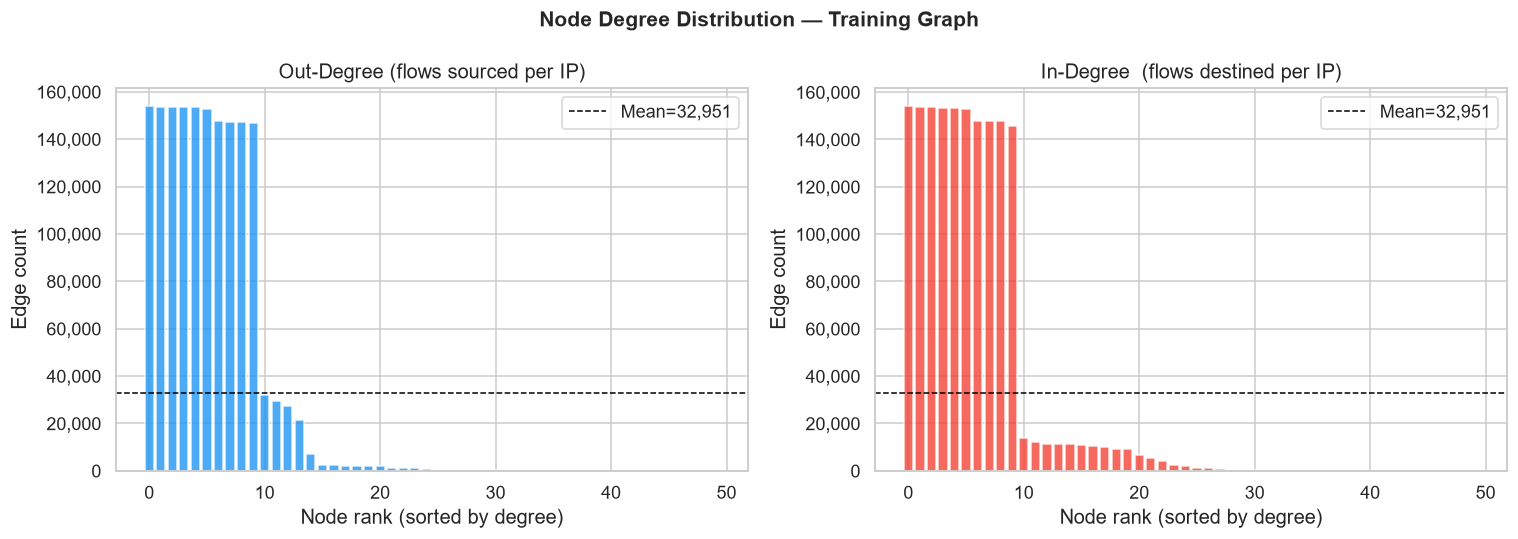

Saved → c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15\outputs\graph\degree_distribution.png


In [12]:
# ── Plot degree distributions (training graph) ────────────────────────────────
in_deg_tr, out_deg_tr = compute_degree_stats(data_train.edge_index, N_NODES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Node Degree Distribution — Training Graph', fontsize=14, fontweight='bold')

for ax, deg, title, color in [
    (axes[0], out_deg_tr, 'Out-Degree (flows sourced per IP)', '#2196F3'),
    (axes[1], in_deg_tr,  'In-Degree  (flows destined per IP)', '#F44336'),
]:
    # Exclude UNK node (index 50) from plot if its degree is 0
    deg_plot = deg[:N_NODES_BASE]  # only known 50 IPs
    ax.bar(range(len(deg_plot)), sorted(deg_plot, reverse=True), color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Node rank (sorted by degree)')
    ax.set_ylabel('Edge count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    mean_d = deg_plot.mean()
    ax.axhline(mean_d, linestyle='--', color='black', linewidth=1, label=f'Mean={mean_d:,.0f}')
    ax.legend()

plt.tight_layout()
out_path = os.path.join(OUT_GRF, 'degree_distribution.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

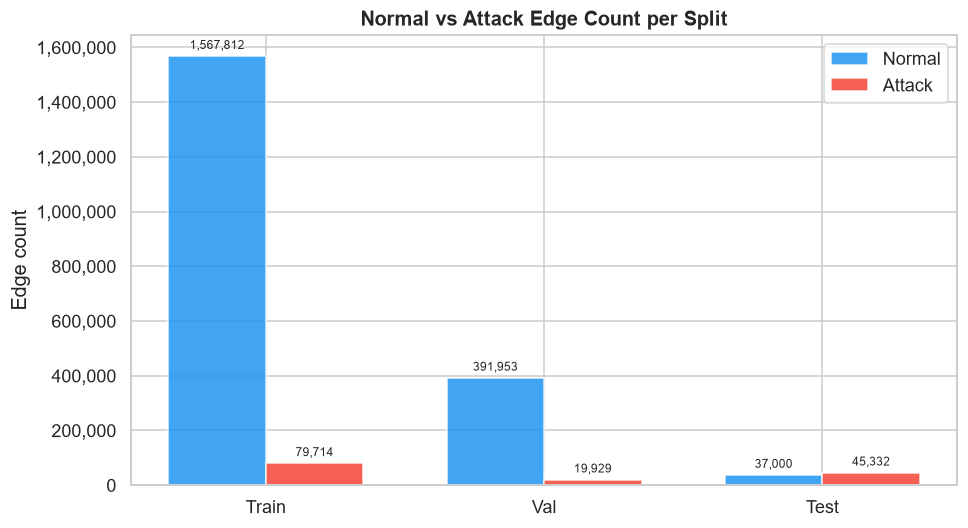

Saved → c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15\outputs\graph\edge_label_distribution.png


In [13]:
# ── Attack vs Normal edge ratio per split ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
splits      = ['Train', 'Val', 'Test']
normal_cnts = [stats[s.lower()]['normal_edges'] for s in splits]
attack_cnts = [stats[s.lower()]['attack_edges'] for s in splits]

x = np.arange(len(splits))
w = 0.35
bars1 = ax.bar(x - w/2, normal_cnts, w, label='Normal', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + w/2, attack_cnts, w, label='Attack', color='#F44336', alpha=0.85)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:,}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

ax.set_title('Normal vs Attack Edge Count per Split', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel('Edge count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend()
plt.tight_layout()
out_path = os.path.join(OUT_GRF, 'edge_label_distribution.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## 3.8 — Serialize

Save the three PyG `Data` objects and the statistics JSON to `outputs/graph/`.

In [14]:
# ── Save PyG Data objects ─────────────────────────────────────────────────────
torch.save(data_train, os.path.join(OUT_GRF, 'graph_data_train.pt'))
torch.save(data_val,   os.path.join(OUT_GRF, 'graph_data_val.pt'))
torch.save(data_test,  os.path.join(OUT_GRF, 'graph_data_test.pt'))

# ── Save graph statistics ─────────────────────────────────────────────────────
stats_payload = {
    'n_nodes'          : N_NODES,
    'n_nodes_known'    : N_NODES_BASE,
    'unk_node_idx'     : UNK_NODE_IDX,
    'node_feat_dim'    : N_NODE_FEAT,
    'edge_feat_dim'    : N_FEAT,
    'n_classes_binary' : 2,
    'n_classes_multi'  : 10,
    'class_names'      : CLASS_NAMES,
    'splits'           : stats,
}
with open(os.path.join(OUT_GRF, 'graph_stats.json'), 'w') as f:
    json.dump(stats_payload, f, indent=2)

print('=== Serialization Complete ===')
for fname in ['graph_data_train.pt', 'graph_data_val.pt',
              'graph_data_test.pt', 'graph_stats.json',
              'degree_distribution.png', 'edge_label_distribution.png']:
    fpath = os.path.join(OUT_GRF, fname)
    size  = os.path.getsize(fpath) / 1e6 if os.path.exists(fpath) else 0
    print(f'  {fname:<35s}  {size:>7.2f} MB')

=== Serialization Complete ===
  graph_data_train.pt                   296.56 MB
  graph_data_val.pt                      74.14 MB
  graph_data_test.pt                     14.82 MB
  graph_stats.json                        0.00 MB
  degree_distribution.png                 0.06 MB
  edge_label_distribution.png             0.03 MB


In [15]:
# ── Verify round-trip load ─────────────────────────────────────────────────────
print('=== Round-trip verify ===')
for split, fname in [('Train', 'graph_data_train.pt'),
                     ('Val',   'graph_data_val.pt'),
                     ('Test',  'graph_data_test.pt')]:
    d_loaded = torch.load(os.path.join(OUT_GRF, fname), weights_only=False)
    ok = d_loaded.validate(raise_on_error=True)
    print(f'  {split:5s}: loaded {fname}  |  validate()={ok}  '
          f'|  edges={d_loaded.num_edges:,}  |  x.dtype={d_loaded.x.dtype}  '
          f'|  edge_index.dtype={d_loaded.edge_index.dtype}  ✓')

=== Round-trip verify ===
  Train: loaded graph_data_train.pt  |  validate()=True  |  edges=1,647,526  |  x.dtype=torch.float32  |  edge_index.dtype=torch.int64  ✓
  Val  : loaded graph_data_val.pt  |  validate()=True  |  edges=411,882  |  x.dtype=torch.float32  |  edge_index.dtype=torch.int64  ✓
  Test : loaded graph_data_test.pt  |  validate()=True  |  edges=82,332  |  x.dtype=torch.float32  |  edge_index.dtype=torch.int64  ✓


In [16]:
# ── Append Phase 3 results to outputs.md ─────────────────────────────────────
tr = stats['train']
va = stats['val']
te = stats['test']

phase3_section = f"""
---

## § Phase 3 — Graph Construction

> Status: ✅ Complete

### 3.1 Graph Schema

```
G = (V, E)  — homogeneous directed graph
  Nodes V  : {N_NODES} total  ({N_NODES_BASE} unique training IPs  +  1 UNK node at index {UNK_NODE_IDX})
  Edges E  : each network flow record  →  directed edge  (srcip → dstip)
  Node feat: [{N_NODES}, {N_NODE_FEAT}]  — RobustScaled, UNK row = zeros
  Edge feat: [E, {N_FEAT}]  — RobustScaled flow-level features (from Phase 2)
  Edge label: y (binary) + y_multi (multiclass, 0–9)
```

### 3.2 Graph Dimensions

| Split | Nodes | Edges | Unique (src,dst) pairs | Density |
|---|---|---|---|---|
| Train | {tr['num_nodes']} | {tr['num_edges']:,} | {tr['unique_src_dst_pairs']} | {tr['graph_density']:.6f} |
| Val   | {va['num_nodes']} | {va['num_edges']:,} | {va['unique_src_dst_pairs']} | {va['graph_density']:.6f} |
| Test  | {te['num_nodes']} | {te['num_edges']:,} | {te['unique_src_dst_pairs']} | {te['graph_density']:.6f} |

### 3.3 Degree Statistics (Training Graph)

| Metric | Out-Degree | In-Degree |
|---|---|---|
| Mean | {tr['mean_out_degree']} | {tr['mean_in_degree']} |
| Max  | {tr['max_out_degree']:,} | {tr['max_in_degree']:,} |

- Weakly-connected components (train): **{tr['weakly_connected_components']}**

> ⚠️ The graph is **extremely dense** — only 50 unique IP nodes but ~1.6M edges.
> Standard `NeighborLoader` will return full-graph subgraphs; batch size tuning required for GNN.

### 3.4 Edge Label Distribution

| Split | Normal | Attack | Attack % |
|---|---|---|---|
| Train | {tr['normal_edges']:,} | {tr['attack_edges']:,} | {tr['attack_edge_ratio']*100:.2f}% |
| Val   | {va['normal_edges']:,} | {va['attack_edges']:,} | {va['attack_edge_ratio']*100:.2f}% |
| Test  | {te['normal_edges']:,} | {te['attack_edges']:,} | {te['attack_edge_ratio']*100:.2f}% |

### 3.5 UNK Node Coverage

- Training IPs in `ip_to_node`: **{N_NODES_BASE}** (all flows in train/val/test use only these IPs)
- UNK node (index {UNK_NODE_IDX}) created with zero features as fallback for unseen IPs
- Node feature scaling: `RobustScaler` fitted on the 50 training-set IPs

### 3.6 Outputs Saved

- `outputs/graph/graph_data_train.pt`   — PyG `Data` object, {tr['num_edges']:,} edges
- `outputs/graph/graph_data_val.pt`     — PyG `Data` object, {va['num_edges']:,} edges
- `outputs/graph/graph_data_test.pt`    — PyG `Data` object, {te['num_edges']:,} edges
- `outputs/graph/graph_stats.json`      — full statistics JSON
- `outputs/graph/degree_distribution.png`
- `outputs/graph/edge_label_distribution.png`
"""

outputs_md_path = os.path.join(BASE, 'outputs.md')
with open(outputs_md_path, 'a', encoding='utf-8') as fh:
    fh.write(phase3_section)

print('outputs.md updated with § Phase 3 results')

outputs.md updated with § Phase 3 results
